# BEE 4750 Mini-Project 1: Dissolved Oxygen with Multiple Effluents

**Names**: Gina Chen, Mikael Murphy-Rendon

**IDs**: cc2859, mm3446

> **Due Date**
>
> Thursday, 10/22/26, 9:00pm

## Overview

Three facilities discharge into the same river. Additionally, there is a
legacy sludge deposit on the riverbed. You will build a model of
dissolved oxygen (DO) along the river, check whether four candidate
treatment plans meet the state standard, test how reliable these plans
are when one facility’s effluent varies from day to day, and recommend a
plan.

### Instructions

- Students in BEE 4750 may work in groups of 2; students in BEE 5750
  work individually.
- Submit a report as a PDF to Gradescope. Make sure to tag pages
  corresponding to a problem in Gradescope.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [1]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `~/BEE 4750/mp01`
   Installed HypergeometricFunctions ─ v0.3.30
   Installed Gamma ─────────────────── v1.2.0
   Installed PDMats ────────────────── v0.11.41
   Installed Accessors ─────────────── v0.1.45
   Installed SpecialFunctions ──────── v2.9.0
   Installed Roots ─────────────────── v3.0.8
   Installed StatsFuns ─────────────── v2.2.1
   Installed Rmath_jll ─────────────── v0.5.2+0
   Installed CompositionsBase ──────── v0.1.2
   Installed InverseFunctions ──────── v0.1.17
   Installed ConstructionBase ──────── v1.6.0
   Installed IJulia ────────────────── v1.34.4
   Installed CommonSolve ───────────── v0.2.14
   Installed ZMQ ───────────────────── v1.5.1
   Installed FillArrays ────────────── v1.17.0
   Installed Rmath ─────────────────── v0.9.0
   Installed Conda ─────────────────── v1.10.3
   Installed Distributions ─────────── v0.25.131
   Installed QuadGK ────────────────── v2.11.3
    Building Conda ─→ `~/.julia/scratchspaces/44cfe95a-1eb2-52ea-b672

In [2]:
using Random
using Statistics
using Distributions
using Plots
using LaTeXStrings

## The System

The river flows at $U = 6$ km/d. The reaeration rate is
$k_a = 0.55\ \text{d}^{-1}$; CBOD and NBOD decay at
$k_c = 0.35\ \text{d}^{-1}$ and $k_n = 0.25\ \text{d}^{-1}$. Saturated
DO is $C_s = 10$ mg/L. Upstream of the first facility the river carries
80,000 m³/d at 6.8 mg/L DO, 4.0 mg/L CBOD, and 3.0 mg/L NBOD.

|             | Facility A | Facility B |                Facility C |
|:------------|-----------:|-----------:|--------------------------:|
| Type        |  municipal |  municipal | food processing (private) |
| Location    |       0 km |      15 km |                     32 km |
| Flow (m³/d) |     22,000 |     10,000 |                    18,000 |
| DO (mg/L)   |        2.0 |        2.5 |                       1.5 |
| CBOD (mg/L) |         66 |         54 |                        80 |
| NBOD (mg/L) |         38 |         30 |                        60 |

Table 1: Effluent characteristics before treatment.

Decades of discharge before the current permits left a bed of settled
organic solids between 20 km and 30 km downstream of Facility A. It
exerts a benthic oxygen demand that is strongest at its upstream edge
and tapers to nothing at its downstream edge:

$$S_B(x) = 1.6\left(1 - \frac{x - 20}{10}\right)\ \text{mg}/(\text{L}\cdot\text{d}) \qquad \text{for } 20 \le x \le 30,$$

and $S_B(x) = 0$ everywhere else.

The relevant regulatory standard from New York State requires DO to stay
at or above **4 mg/L** at every point in the river.

As treatment options, each facility can install one level of treatment,
which removes the given fraction of both CBOD and NBOD from its
effluent. Costs are annualized, in thousands of dollars per year.

| Level     | Removal | Facility A | Facility B | Facility C |
|:----------|--------:|-----------:|-----------:|-----------:|
| None      |      0% |          0 |          0 |          0 |
| Primary   |     35% |        310 |        180 |        265 |
| Secondary |     65% |        720 |        395 |        640 |
| Tertiary  |     85% |      1,450 |        810 |      1,980 |

Table 2: Treatment levels and annualized costs (\$1,000/yr).

The regional water authority is considering four plans:

| Plan | Facility A | Facility B | Facility C | Annual cost |
|:-----|:-----------|:-----------|:-----------|------------:|
| 1    | secondary  | primary    | primary    | \$1,165,000 |
| 2    | secondary  | secondary  | primary    | \$1,380,000 |
| 3    | secondary  | primary    | secondary  | \$1,540,000 |
| 4    | tertiary   | primary    | primary    | \$1,895,000 |

Table 3: Candidate treatment plans.

Here is this information summarized for you:

In [3]:
river_params = let
    ka, kc, kn = 0.55, 0.35, 0.25   # reaeration, CBOD decay, NBOD decay   [1/d]
    Cs, U = 10, 6                   # saturation DO [mg/L], velocity [km/d]
    (; ka, kc, kn, Cs, U)
end

# Conditions in the river upstream of Facility A
river_flow = 80_000     # [m³/d]
river_DO   = 6.8        # [mg/L]
river_CBOD = 4          # [mg/L]
river_NBOD = 3          # [mg/L]

# One entry per facility, in order going downstream: A, B, C
facility_location = [0, 15, 32]            # [km]
facility_flow     = [22_000, 10_000, 18_000]  # [m³/d]
facility_DO       = [2, 2.5, 1.5]          # [mg/L]
# Float64 arrays, so a Monte Carlo draw can be stored in them
facility_CBOD     = Float64[66, 54, 80]    # [mg/L], before treatment
facility_NBOD     = Float64[38, 30, 60]    # [mg/L], before treatment

# Benthic oxygen demand from the sludge bed [mg/(L·d)]
function sludge_demand(x)
    if 20 <= x <= 30
        return 1.6 * (1 - (x - 20) / 10)
    else
        return 0
    end
end

# Treatment levels, in order: none, primary, secondary, tertiary
treatment_removal = [0, 0.35, 0.65, 0.85]
# Annualized cost [$1,000/yr]; one row per facility (A, B, C), one column per level
treatment_cost = [0 310 720 1450;
                  0 180 395 810;
                  0 265 640 1980]

# Fraction of CBOD and NBOD removed at facilities A, B, C under each candidate plan
plan_removal = [
    [0.65, 0.35, 0.35],   # Plan 1
    [0.65, 0.65, 0.35],   # Plan 2
    [0.65, 0.35, 0.65],   # Plan 3
    [0.85, 0.35, 0.35],   # Plan 4
]
plan_cost = [1.165e6, 1.380e6, 1.540e6, 1.895e6]   # [$/yr]

4-element Vector{Float64}:
 1.165e6
 1.38e6
 1.54e6
 1.895e6

## Parts (Total: 100 Points)

### Part 1 (15) - Mikael

Model DO, CBOD, and NBOD as functions of distance from Facility A to 70
km downstream.

#### Part 1.1 (4)

Explain why you cannot used the closed-form Streeter-Phelps solution to
model this system.

#### **Answer:** 
* The single source and sink assumption is violated since this scenario has three facilities all discharging waste into the same river.
* The original model only accounts for constant reaeration and first order decay of CBOD and NBOD. This scenario also has a benthic oxygen demand that varies spatially along the length of the river, which is not-constant.
Since the single source&sink and the constant oxygen demand assumptions are not met, this scenario has non-continuous inputs and a non-constant sink that prevent use from using the regular closed-form method.

#### Part 1.2 (4)

Write the forward Euler update rules for DO, CBOD, and NBOD in terms of
distance, including the sludge bed. Mix each effluent into the river at
the grid point at the facility’s location; choose step sizes that put a
grid point exactly at 15 km and 32 km.

#### Part 1.3 (7)

Implement your model and plot DO against distance with **no treatment**
at any facility. Mark the standard on the plot. Where is DO lowest, how
low does it get, and why does the lowest point fall there rather than
just after an effluent?

#### **Answer:**
Dissolved oxygen is at the lowest around 41 km from Facility A, and it reaches a low of 0.1277 mg/L, which is much lower than the New York State Regulation. The lowest point occurs after all of the facility effluent locations because of the time delay between the waste entering the water and the bacterial populations actually consuming it. As the waste takes time to travel in the water downstream, the lowest dissolved oxygen level (where the bacteria are most active) will occur downriver.

In [36]:
do_change(C, B, N,x, params) =
    (params.ka * (params.Cs - C) - params.kc * B
     - params.kn * N - sludge_demand(x))/params.U

function simulate_river(L, Δx, params, removal)
    steps = round(Int, L / Δx)
    x = collect(0:Δx:L)
    B = zeros(steps + 1)
    N = zeros(steps + 1)
    C = zeros(steps + 1)

    Q = river_flow
    B_current, N_current, C_current = river_CBOD, river_NBOD, river_DO
    
    j = 1
    # Mix Facility A at x = 0 for the initial influent values
    while j <= length(facility_location) && isapprox(x[1],facility_location[j],atol=1e-10)
        B_current, N_current, C_current, Q =
            effluent_mixing(B_current, N_current, C_current, Q,
                facility_flow[j], facility_CBOD[j], facility_NBOD[j],
                facility_DO[j], removal[j])
        j += 1
    end

    B[1], N[1], C[1] = B_current, N_current, C_current

    for i in 1:steps
        x_i = x[i]
        B_next = B[i] + Δx * (-params.kc / params.U) * B[i]
        N_next = N[i] + Δx * (-params.kn / params.U) * N[i]
        C_next = C[i] + Δx * do_change(C[i], B[i], N[i], x_i, params)

        # Mix a discharge at the grid point
        while j <= length(facility_location) && isapprox(x[i+1],facility_location[j],atol=1e-10)
            B_next, N_next, C_next, Q =
                effluent_mixing(B_next, N_next, C_next, Q,
                    facility_flow[j], facility_CBOD[j], facility_NBOD[j],
                    facility_DO[j], removal[j])
            j += 1
        end

        B[i + 1], N[i + 1], C[i + 1] = B_next, N_next, C_next
    end
    C_min = round(minimum(C),digits=4)
    loc_min = argmin(C)
    return x, C, B, N, C_min, loc_min
end

function effluent_mixing(B, N, DO, Q_river, Q_effluent,
                         B_effluent, N_effluent, DOeffluent, removal)
    Q_new = Q_river + Q_effluent
    B_mix = (Q_river * B + Q_effluent * (1 - removal) * B_effluent) / Q_new
    N_mix = (Q_river * N + Q_effluent * (1 - removal) * N_effluent) / Q_new
    DO_mix = (Q_river * DO + Q_effluent * DOeffluent) / Q_new
    return B_mix, N_mix, DO_mix, Q_new
end

effluent_mixing (generic function with 1 method)

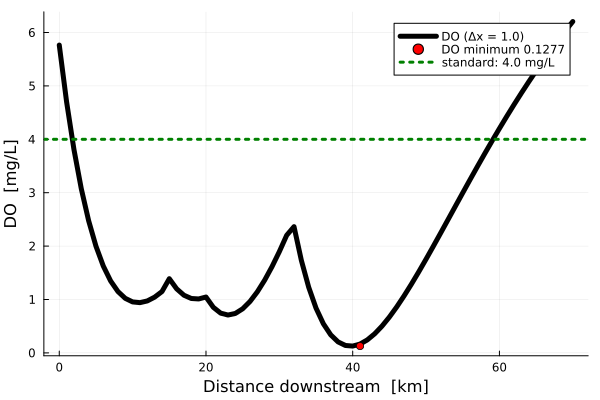

In [60]:
L = 70.0 #km
step = 1 #km
x, C, B, N, C_min, loc_min = simulate_river(L, step, river_params, [0,0,0])
p_sag = plot(xlabel="Distance downstream  [km]", ylabel="DO  [mg/L]", legend=:topright)
plot!(p_sag, x, C, color=:black, linewidth=5, label="DO (Δx = 1.0)")
scatter!(p_sag, [loc_min*step],[C_min], color=:red, label="DO minimum $C_min")
hline!(p_sag, [4.0], color=:green, linewidth=3, linestyle=:dot, label="standard: 4.0 mg/L")

#println(C_min)
# println(loc_min)

### Part 2 (15) - Gina

#### Part 2.1 (9)

Run a convergence study on the **minimum DO** with no treatment. Build a
reference solution at a very fine step, then test a sequence of
successively halved step sizes against it. Report a table of step sizes,
minimum DO, error against the reference, and the improvement between
resolution sizes, then plot error against step size on log-log axes.

#### Part 2.2 (6)

State the step size you will use for the rest of the project and justify
it. Does the slope match what we expect for forward Euler?

### Part 3 (20)

#### Part 3.1 (8)

Evaluate the four plans in
<a href="#tbl-plans" class="quarto-xref">Table 3</a>. For each, report
the minimum DO, where it occurs, and whether the plan complies with the
standard. Plot the four DO profiles on the same set of axes with the
standard marked with a dashed red line.

#### Part 3.2 (6)

Plan 4 is the most expensive of the four, yet it leaves less margin
above the standard than Plan 3. Explain why.

#### Part 3.3 (6)

The authority could instead dredge the sludge bed, which corresponds to
removing it from your model. How much does the minimum DO change with no
treatment, and how much of the original violation does that account for?
Would this change the effectiveness of any of the plans?

### Part 4 (30)

Suppose Facility C’s waste stream varies from day to day: its dissolved
oxygen, untreated CBOD, and untreated NBOD all change together. Assume
they are independent, with

| Facility C effluent    | Distribution (mg/L)                    |
|:-----------------------|:---------------------------------------|
| DO                     | $\mathcal{N}(1.5,\ 0.5^2)$, at least 0 |
| CBOD, before treatment | $\mathcal{N}(80,\ 12^2)$               |
| NBOD, before treatment | $\mathcal{N}(60,\ 9^2)$                |

and everything else as before. Each Monte Carlo sample should draw all
three.

#### Part 4.1 (8)

For each plan that complied in Part 3, and for Plan 1 with the sludge
bed dredged, estimate the probability that the river violates the
standard on a randomly chosen day. Report each estimate with a 95%
confidence interval, your sample size, and your seed. If a plan produces
no violations in your sample, say what that does and does not tell you
about its probability of violating. Finally, is it reasonable to draw
Facility C’s three quantities independently? If not, which way would
that push your estimates?

#### Part 4.2 (8)

Your estimate for Plan 2 involves two sources of error: one from the
discretization step size $\Delta x$, one from the Monte Carlo sample
size $n$. They can be compared by examining their influence on the same
modeled quantity of interest. Let’s use the violation probability.

Hold $n$ and the random seed fixed and vary $\Delta x$; then hold
$\Delta x$ fixed and vary $n$. Report both as a table. Which error is
larger at the settings you used in 4.1, and, if you could spend some
time reducing one, which would be the most useful?

#### Part 4.3 (4)

Your confidence interval reports one of those two errors and is silent
about the other. Which one, and what might a reader who just encounters
your interval wrongly conclude?

#### Part 4.4 (10)

The four candidates are only 4 of the 64 ways to assign treatment levels
to the three facilities
(<a href="#tbl-treatment" class="quarto-xref">Table 2</a>). Find the
cheapest plan whose probability of violating the standard is below 5%,
without running Monte Carlo on all 64. First **screen** every plan with
your deterministic model at average conditions, with each of Facility
C’s three quantities at its mean; then **sample**, running Monte Carlo
only on plans that pass the screen, starting from the cheapest.

Report how many plans pass the screen, which plans you sampled, and the
plan you find. Then explain why the screen is safe here: could a plan
that fails it still have a violation probability below 5%?

### Part 5 (20)

You are the engineer retained by the regional water authority, which
must select one plan and defend it publicly. Facilities A and B are
municipal and will pass their costs on to ratepayers; Facility C is a
private food processor that will bear its own.

#### Part 5.1 (8)

Recommend one plan. Justify the choice, and explain how you weighed its
cost against its probability of violating the standard.

#### Part 5.2 (7)

The authority’s board includes members who prioritize ratepayer cost,
members who prioritize river condition, and members concerned with how
the burden falls between municipal and private dischargers. Which plan
would each group favor, and why? Does your recommendation change under
any of these priorities?

#### Part 5.3 (5)

What information, not available to you here, would most change your
recommendation?

## References

List any external references consulted, including classmates.